## A notebook to pre-visualize and pre-process 3D skin data with biomarkers

In [1]:
# install and load libraries
%pip install plotly nbformat pandas matplotlib seaborn

import plotly.graph_objects as go
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached jsonschema-4.23.0-py3-none-any.whl.metadata (7.9 kB)
  Using cached jsonschema_specifications-2024.10.1-py3-none-any.whl.metadata (3.0 kB)
Using cached nbformat-5.10.4-py3-none-any.whl (78 kB)
Using cached jsonschema-4.23.0-py3-none-any.whl (88 kB)
Using cached jsonschema_specifications-2024.10.1-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
# load data
df_data = pd.read_csv(
    'data/F8iic-quantificationV3.csv').head(100)
df_data

C:\Users\abueckle\AppData\Local\Temp\1\ipykernel_37176\3552394558.py:2: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df_data = pd.read_csv(


,CELLID,5hmc,MART1,HLA-AB,SOX10,S100B,panCK,laminABC,S100A,CD31,...,volume,X_centroid,Y_centroid,Z_centroid,1_axislength,2_axislength,3_axislength,1_eigen,2_eigen,3-eigen
0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,0.000,0.000,0.0000,0.000,0.0000,0.0000
1,2,0.000,0.000,203.53,104.5500,13.683,104.2400,351.2100,412.5900,32.1880,...,1418.0,732.21,18.569,0.87001,26.972,16.836,6.4192,36.373,14.1730,2.0603
2,3,66.405,63.902,838.22,357.7700,650.460,101.6800,31.9760,368.4600,14.9850,...,205.0,733.07,22.936,4.77910,17.943,12.617,7.5335,16.097,7.9597,2.8377
3,4,0.000,0.000,1121.90,371.0600,1191.500,89.6570,87.4350,50.7870,17.3900,...,577.0,736.84,29.739,4.43490,14.877,10.633,7.4977,11.066,5.6526,2.8107
4,5,1056.200,2790.500,1090.10,450.3900,1395.600,46.6260,100.2700,201.5900,7.0120,...,29171.0,732.12,143.700,15.22900,259.440,89.697,50.3700,3365.400,402.2800,126.8600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,622.690,1098.900,373.27,93.7350,2138.200,154.2500,241.8900,190.7400,18.0450,...,49108.0,759.61,42.954,17.02600,242.580,110.580,28.6630,2942.100,611.4000,41.0790
96,97,760.550,1731.400,1339.40,1953.5000,5248.400,78.3390,93.4310,5.8748,3.0705,...,26436.0,757.14,132.220,7.29320,53.723,39.702,25.8300,144.310,78.8120,33.3590
97,98,499.600,1419.700,1006.50,504.1000,3000.600,2.7752,3.8389,0.0000,0.0000,...,14880.0,754.90,169.500,6.54920,34.493,33.430,30.0020,59.488,55.8770,45.0060
98,99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,0.000,0.000,0.0000,0.000,0.0000,0.0000


In [3]:
# make correlation table
biomarkers = ['MART1', 'SOX10', 'CD31', 'pMLC2','CD163','CD8a','FOXP3','SOX9']

df_interest = df_data[biomarkers]

# Convert all columns to numeric, setting errors='coerce' replaces non-numeric values with NaN
df_numeric = df_interest.apply(pd.to_numeric, errors='coerce')

# Compute correlation matrix, NaN values are ignored
correlation_matrix = df_numeric.corr()

print(correlation_matrix)

          MART1     SOX10      CD31     pMLC2     CD163      CD8a     FOXP3  \
MART1  1.000000  0.014999 -0.027811 -0.158826 -0.002553  0.019400  0.128881   
SOX10  0.014999  1.000000 -0.056813 -0.289587 -0.024727 -0.103634 -0.019839   
CD31  -0.027811 -0.056813  1.000000 -0.082520  0.225788  0.246910  0.183896   
pMLC2 -0.158826 -0.289587 -0.082520  1.000000 -0.190037 -0.068820 -0.099085   
CD163 -0.002553 -0.024727  0.225788 -0.190037  1.000000  0.204754  0.568784   
CD8a   0.019400 -0.103634  0.246910 -0.068820  0.204754  1.000000  0.152571   
FOXP3  0.128881 -0.019839  0.183896 -0.099085  0.568784  0.152571  1.000000   
SOX9  -0.122492 -0.067904  0.057315 -0.115750  0.670274  0.028539  0.144879   

           SOX9  
MART1 -0.122492  
SOX10 -0.067904  
CD31   0.057315  
pMLC2 -0.115750  
CD163  0.670274  
CD8a   0.028539  
FOXP3  0.144879  
SOX9   1.000000  


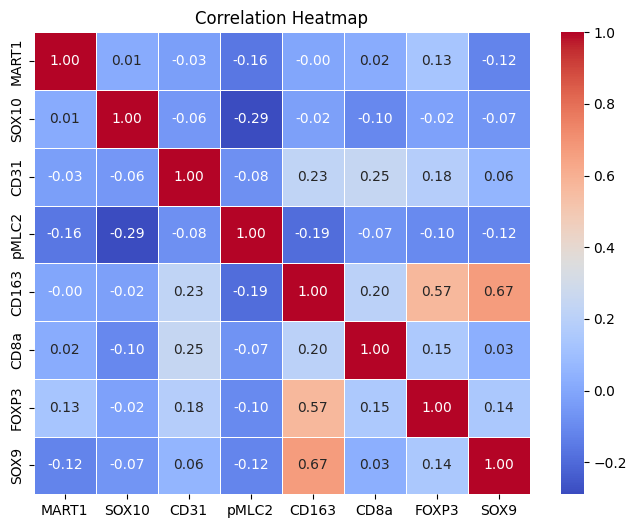

In [4]:
# visualize as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',
            fmt=".2f", linewidths=0.5)

# Show the plot
plt.title("Correlation Heatmap")
plt.show()

In [5]:
# Create 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    # x=df_data['SOX9'],
    # y=df_data['CD163'],
    # z=df_data['FOXP3'],
    x=df_data['X_centroid'],
    y=df_data['Y_centroid'],
    z=df_data['Z_centroid'],
    mode='markers',
    marker=dict(
        # size=df_data['volume']/3000,  # Marker size
        color=df_data['volume'],
        colorscale='Viridis',  # Color scale
        opacity=0.8  # Transparency
    )
)])

# Add title and labels
fig.update_layout(
    title="3D Scatter Plot",
)

fig.show()